##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [2]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

I ran into too many issues trying to use the same method as lab 7, so i did it manually

In [8]:
dataset_directory = "/Users/ykalsuhaili/Downloads/action_youtube_naudio"

# Verify it works
print(os.listdir(dataset_directory))

['volleyball_spiking', 'golf_swing', 'swing', 'tennis_swing', 'soccer_juggling', 'horse_riding', 'walking', 'basketball', 'trampoline_jumping', 'biking', 'readme.txt', 'diving']


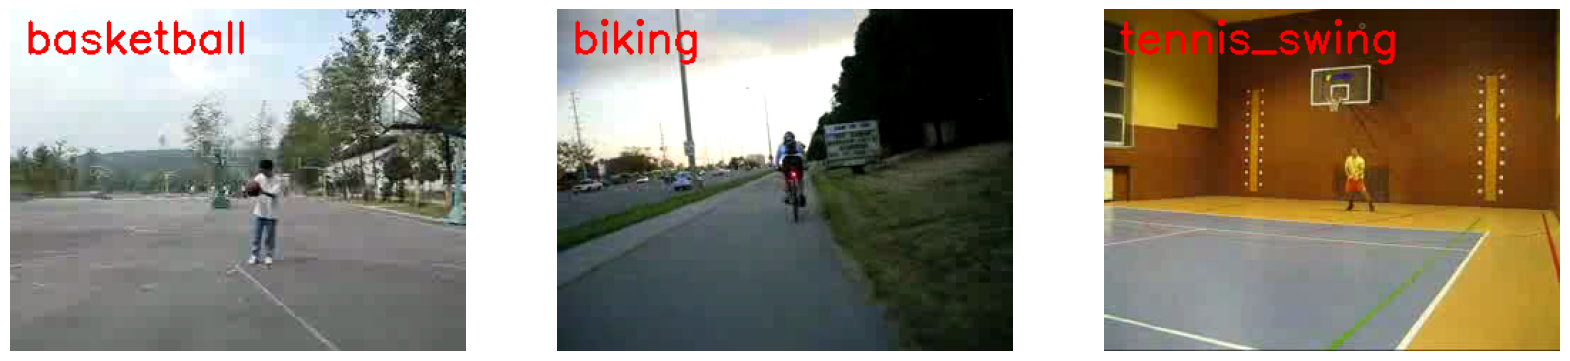

In [9]:
classes_list = ["basketball", "biking", "tennis_swing"]

plt.figure(figsize=(20, 6))

for counter, class_name in enumerate(classes_list, 1):

    class_path = os.path.join(dataset_directory, class_name)
    group_folders = os.listdir(class_path)

    selected_group = random.choice(group_folders)
    group_path = os.path.join(class_path, selected_group)
    video_files_list = os.listdir(group_path)
    selected_video_file_name = random.choice(video_files_list)

    video_reader = cv2.VideoCapture(os.path.join(group_path, selected_video_file_name))
    _, bgr_frame = video_reader.read()
    video_reader.release()

    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    cv2.putText(rgb_frame, class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    plt.subplot(1, 3, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')

plt.show()

In [10]:
image_height, image_width = 64, 64
max_images_per_class = 2000

model_output_size = len(classes_list)

In [11]:
def frames_extraction(video_path):
    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

In [12]:
def create_dataset():
    temp_features = []
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}')

        class_path = os.path.join(dataset_directory, class_name)

        for group_folder in os.listdir(class_path):
            group_path = os.path.join(class_path, group_folder)

            if not os.path.isdir(group_path):
                continue

            for file_name in os.listdir(group_path):
                if not file_name.endswith(('.avi', '.mp4')):
                    continue

                video_file_path = os.path.join(group_path, file_name)
                frames = frames_extraction(video_file_path)
                temp_features.extend(frames)

        sample_size = min(max_images_per_class, len(temp_features))
        features.extend(random.sample(temp_features, sample_size))
        labels.extend([class_index] * sample_size)

        print(f'  -> {sample_size} frames extracted for "{class_name}"')
        temp_features.clear()

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels

In [13]:
features, labels = create_dataset()

print(f"Features shape: {features.shape}")
print(f"Labels shape:   {labels.shape}")

Extracting Data of Class: basketball
  -> 2000 frames extracted for "basketball"
Extracting Data of Class: biking
  -> 2000 frames extracted for "biking"
Extracting Data of Class: tennis_swing
  -> 2000 frames extracted for "tennis_swing"
Features shape: (6000, 64, 64, 3)
Labels shape:   (6000,)


In [14]:
one_hot_encoded_labels = to_categorical(labels)

In [15]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

print(f"Training set:  {features_train.shape[0]} samples")
print(f"Testing set:   {features_test.shape[0]} samples")

Training set:  4800 samples
Testing set:   1200 samples


In [16]:
def create_model():
    model = Sequential([
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
               input_shape=(image_height, image_width, 3)),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dense(model_output_size, activation='softmax')
    ])

    model.summary()
    return model

model = create_model()
print("Model Created Successfully!")

/opt/anaconda3/envs/video-classification/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


In [17]:
plot_model(model, to_file='model_structure_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [18]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss', patience=15, mode='min', restore_best_weights=True
)

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

model_training_history = model.fit(
    x=features_train, y=labels_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.7318 - loss: 0.6505 - val_accuracy: 0.3240 - val_loss: 1.0954
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 185ms/step - accuracy: 0.8940 - loss: 0.2978 - val_accuracy: 0.4490 - val_loss: 1.0549
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 24s 199ms/step - accuracy: 0.9336 - loss: 0.1907 - val_accuracy: 0.4198 - val_loss: 1.0238
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9497 - loss: 0.1397 - val_accuracy: 0.9094 - val_loss: 0.4101
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.9638 - loss: 0.1110 - val_accuracy: 0.7646 - val_loss: 0.5301
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 182ms/step - accuracy: 0.9693 - loss: 0.0854 - val_accuracy: 0.9552 - val_loss: 0.1340
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.9805 - loss: 0.0608 - val_accuracy: 0.9552 - val_loss: 0.1492
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.9789 - loss: 0

In [19]:
model_evaluation_history = model.evaluate(features_test, labels_test)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

print(f"Test Loss:     {model_evaluation_loss:.4f}")
print(f"Test Accuracy: {model_evaluation_accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9967 - loss: 0.0096
Test Loss:     0.0096
Test Accuracy: 0.9967


In [20]:
student_name = "AlyamamaKhalid"  # <-- Replace with your actual name
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as: {save_path}")

Model saved as: AlyamamaKhalid_ucf11_model.h5


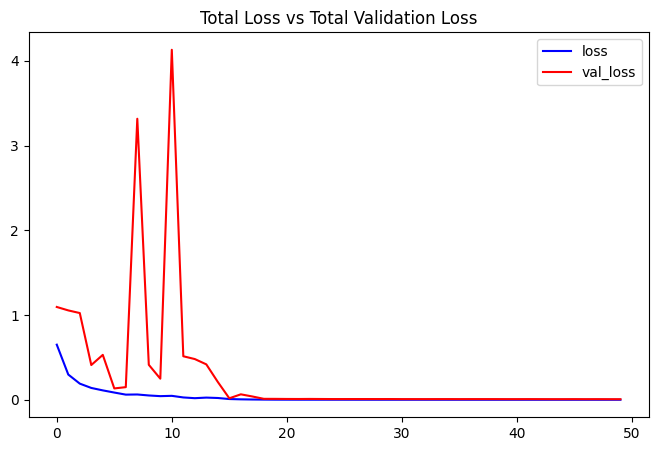

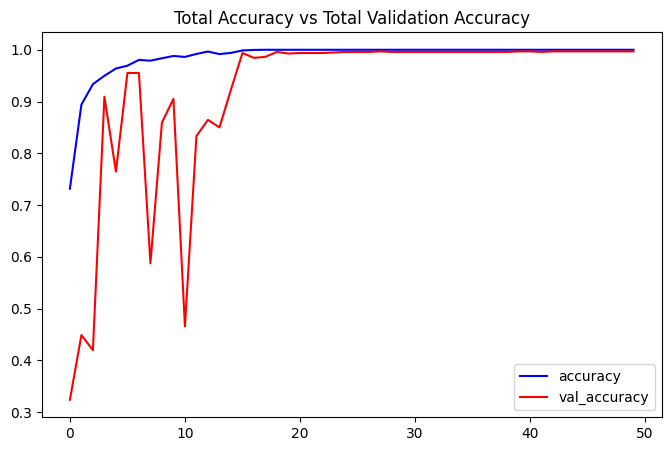

In [21]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    epochs = range(len(metric_value_1))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metric_value_1, 'blue', label=metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label=metric_name_2)
    plt.title(plot_name)
    plt.legend()
    plt.show()

plot_metric('loss', 'val_loss', 'Total Loss vs Total Validation Loss')
plot_metric('accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

In [22]:
def predict_on_live_video(video_file_path, output_file_path, window_size):
    predicted_labels_probabilities_deque = deque(maxlen=window_size)

    video_reader = cv2.VideoCapture(video_file_path)
    original_video_width  = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_writer = cv2.VideoWriter(
        output_file_path,
        cv2.VideoWriter_fourcc('M', 'P', '4', 'V'),
        24,
        (original_video_width, original_video_height)
    )

    while True:
        status, frame = video_reader.read()
        if not status:
            break

        resized_frame    = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        if len(predicted_labels_probabilities_deque) == window_size:
            predicted_labels_probabilities_np       = np.array(predicted_labels_probabilities_deque)
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
            predicted_label      = np.argmax(predicted_labels_probabilities_averaged)
            predicted_class_name = classes_list[predicted_label]
            confidence           = predicted_labels_probabilities_averaged[predicted_label]

            cv2.putText(frame, f"{predicted_class_name} ({confidence:.2f})",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        video_writer.write(frame)

    video_reader.release()
    video_writer.release()
    print(f"Output saved to: {output_file_path}")

In [28]:
def make_average_predictions(video_file_path, predictions_frames_count):
    predicted_labels_probabilities_np = np.zeros(
        (predictions_frames_count, model_output_size), dtype=float
    )

    video_reader       = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = video_frames_count // predictions_frames_count

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        _, frame = video_reader.read()

        resized_frame    = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
    sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    print(f"\nResults for: {video_file_path}")
    for predicted_label in sorted_indexes:
        predicted_class_name  = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS NAME: {predicted_class_name:<25} AVERAGED PROBABILITY: {predicted_probability:.2f}")

    video_reader.release()

In [ ]:
!pip install -q yt-dlp

import yt_dlp

video_urls = [
    "https://youtu.be/Dd81zHyH8QU",  # basketball
    "https://youtu.be/e17amh9PZTg",  # biking
    "https://youtu.be/1ZSDIK23T7o"   # tennis_swing
]

os.makedirs("Youtube_Videos", exist_ok=True)

for i, url in enumerate(video_urls):
    ydl_opts = {
        'outtmpl': f'Youtube_Videos/video_{i}.%(ext)s',
        'format': 'bv*+ba/b',
        'merge_output_format': 'mp4',
        'quiet': False
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

print(os.listdir("Youtube_Videos"))

[youtube] Extracting URL: https://youtu.be/Dd81zHyH8QU
[youtube] Dd81zHyH8QU: Downloading webpage


[youtube] Dd81zHyH8QU: Downloading android vr player API JSON
[info] Dd81zHyH8QU: Downloading 1 format(s): 398+251
[download] Destination: Youtube_Videos/video_0.f398.mp4
[download] 100% of    2.71MiB in 00:00:02 at 1.24MiB/s   
[download] Destination: Youtube_Videos/video_0.f251.webm
[download] 100% of  215.38KiB in 00:00:01 at 143.27KiB/s 
[Merger] Merging formats into "Youtube_Videos/video_0.mp4"
Deleting original file Youtube_Videos/video_0.f398.mp4 (pass -k to keep)
Deleting original file Youtube_Videos/video_0.f251.webm (pass -k to keep)
[youtube] Extracting URL: https://youtu.be/e17amh9PZTg
[youtube] e17amh9PZTg: Downloading webpage


[youtube] e17amh9PZTg: Downloading android vr player API JSON
[info] e17amh9PZTg: Downloading 1 format(s): 399+251
[download] Destination: Youtube_Videos/video_1.f399.mp4
[download] 100% of  105.92MiB in 00:00:33 at 3.14MiB/s     
[download] Destination: Youtube_Videos/video_1.f251.webm
[download] 100% of    2.17MiB in 00:00:01 at 1.51MiB/s   
[Merger] Merging formats into "Youtube_Videos/video_1.mp4"
Deleting original file Youtube_Videos/video_1.f399.mp4 (pass -k to keep)
Deleting original file Youtube_Videos/video_1.f251.webm (pass -k to keep)
[youtube] Extracting URL: https://youtu.be/1ZSDIK23T7o
[youtube] 1ZSDIK23T7o: Downloading webpage


[youtube] 1ZSDIK23T7o: Downloading android vr player API JSON
[info] 1ZSDIK23T7o: Downloading 1 format(s): 399+251
[download] Destination: Youtube_Videos/video_2.f399.mp4
[download] 100% of   38.44MiB in 00:00:05 at 7.28MiB/s     
[download] Destination: Youtube_Videos/video_2.f251.webm
[download] 100% of    4.84MiB in 00:00:00 at 5.58MiB/s   
[Merger] Merging formats into "Youtube_Videos/video_2.mp4"
Deleting original file Youtube_Videos/video_2.f251.webm (pass -k to keep)
Deleting original file Youtube_Videos/video_2.f399.mp4 (pass -k to keep)
['video_2.mp4', 'video_1.mp4', 'video_0.mp4']


In [31]:
converted_video_paths = []

for i in range(len(video_urls)):
    input_path = f"Youtube_Videos/video_{i}.mp4"
    output_path = f"Youtube_Videos/converted_{i}.mp4"
    os.system(f'ffmpeg -y -i "{input_path}" -c:v libx264 -pix_fmt yuv420p -c:a aac "{output_path}"')
    converted_video_paths.append(output_path)

print("Converted videos:", converted_video_paths)

ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.4.4.1)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --

Converted videos: ['Youtube_Videos/converted_0.mp4', 'Youtube_Videos/converted_1.mp4', 'Youtube_Videos/converted_2.mp4']


[out#0/mp4 @ 0x75106c300] video:86008KiB audio:4392KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.205930%
frame= 6605 fps= 82 q=-1.0 Lsize=   90586KiB time=00:04:35.40 bitrate=2694.6kbits/s speed=3.41x elapsed=0:01:20.87    
[libx264 @ 0x751069180] frame I:60    Avg QP:17.13  size:140929
[libx264 @ 0x751069180] frame P:1857  Avg QP:20.21  size: 27025
[libx264 @ 0x751069180] frame B:4688  Avg QP:25.37  size:  6278
[libx264 @ 0x751069180] consecutive B-frames:  3.5%  3.5%  6.2% 86.8%
[libx264 @ 0x751069180] mb I  I16..4: 14.4% 73.7% 11.9%
[libx264 @ 0x751069180] mb P  I16..4:  3.6% 10.3%  0.7%  P16..4: 28.3%  8.7%  4.7%  0.0%  0.0%    skip:43.8%
[libx264 @ 0x751069180] mb B  I16..4:  0.4%  0.8%  0.1%  B16..8: 25.1%  1.8%  0.3%  direct: 1.0%  skip:70.6%  L0:45.4% L1:49.1% BI: 5.4%
[libx264 @ 0x751069180] 8x8 transform intra:70.3% inter:79.6%
[libx264 @ 0x751069180] coded y,uvDC,uvAC intra: 39.3% 41.3% 14.9% inter: 7.2% 7.0% 0.2%
[libx264 @ 0x751069180] i16 v,h

In [32]:
for video_path in converted_video_paths:
    cap = cv2.VideoCapture(video_path)
    ok, frame = cap.read()
    print(video_path, "readable:", ok)
    cap.release()

Youtube_Videos/converted_0.mp4 readable: True
Youtube_Videos/converted_1.mp4 readable: True
Youtube_Videos/converted_2.mp4 readable: True


In [33]:
for i, video_path in enumerate(converted_video_paths):
    print(f"\n--- Video {i+1}: {classes_list[i]} ---")
    make_average_predictions(video_path, predictions_frames_count=40)
    
    output_path = f"Youtube_Videos/output_{i}.mp4"
    predict_on_live_video(video_path, output_path, window_size=25)


--- Video 1: basketball ---

Results for: Youtube_Videos/converted_0.mp4
CLASS NAME: biking                    AVERAGED PROBABILITY: 1.00
CLASS NAME: basketball                AVERAGED PROBABILITY: 0.00
CLASS NAME: tennis_swing              AVERAGED PROBABILITY: 0.00


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Output saved to: Youtube_Videos/output_0.mp4

--- Video 2: biking ---

Results for: Youtube_Videos/converted_1.mp4
CLASS NAME: biking                    AVERAGED PROBABILITY: 0.75
CLASS NAME: basketball                AVERAGED PROBABILITY: 0.22
CLASS NAME: tennis_swing              AVERAGED PROBABILITY: 0.03


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Output saved to: Youtube_Videos/output_1.mp4

--- Video 3: tennis_swing ---

Results for: Youtube_Videos/converted_2.mp4
CLASS NAME: tennis_swing              AVERAGED PROBABILITY: 0.63
CLASS NAME: biking                    AVERAGED PROBABILITY: 0.25
CLASS NAME: basketball                AVERAGED PROBABILITY: 0.12


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Output saved to: Youtube_Videos/output_2.mp4
